# Lecture 7: Image Segmentation

In [46]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# Package imports
import os
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
import torch.nn.functional as F


In [48]:
# Navigate into the desired folder
%cd /content/drive/MyDrive/NECST/PiA/Lezione7

/content/drive/MyDrive/NECST/PiA/Lezione7


## Organize dataset into a Pandas dataframe

In [50]:
# As last time, we store all image paths into a pandas dataframe, but this time we also store the paths of corresponding masks
images_base_path = 'images'
masks_base_path = 'masks'

image_paths = []
mask_paths = []
classes = []

for class_name in os.listdir(images_base_path):
    class_image_folder = os.path.join(images_base_path, class_name)
    class_mask_folder = os.path.join(masks_base_path, class_name)

    if os.path.isdir(class_image_folder) and os.path.isdir(class_mask_folder):
        for image_file in os.listdir(class_image_folder):
            # this procedure works because i know that images and corresponding masks have the same name. The only thing it changes, is the folder
            if image_file.endswith('.png'):
                img_path = os.path.join(class_image_folder, image_file)
                msk_path = os.path.join(class_mask_folder, image_file) # Mask file has the same name as image file

                if os.path.exists(msk_path):
                    image_paths.append(img_path)
                    mask_paths.append(msk_path)
                    classes.append(class_name)
                else:
                    print(f"Mask not found for image: {img_path}")

# Create the pandas DataFrame
df = pd.DataFrame({"image_path": image_paths, "mask_path": mask_paths, "class": classes})

print(f"DataFrame created with {len(df)} entries.")
print(df.head())

DataFrame created with 308 entries.
                                      image_path  \
0  images/Adenocarcinoma/GT2001837-1-400-002.png   
1  images/Adenocarcinoma/GT2001849-1-400-002.png   
2  images/Adenocarcinoma/GT2001849-1-400-007.png   
3  images/Adenocarcinoma/GT2001838-1-400-003.png   
4  images/Adenocarcinoma/GT2001837-1-400-001.png   

                                      mask_path           class  
0  masks/Adenocarcinoma/GT2001837-1-400-002.png  Adenocarcinoma  
1  masks/Adenocarcinoma/GT2001849-1-400-002.png  Adenocarcinoma  
2  masks/Adenocarcinoma/GT2001849-1-400-007.png  Adenocarcinoma  
3  masks/Adenocarcinoma/GT2001838-1-400-003.png  Adenocarcinoma  
4  masks/Adenocarcinoma/GT2001837-1-400-001.png  Adenocarcinoma  


## Visualize one random sample

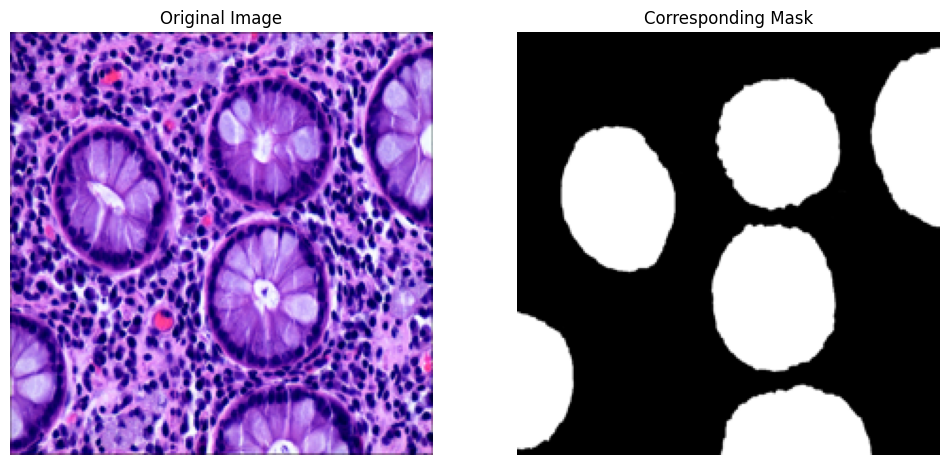

In [51]:
# select a random index and display image and corresponding mask
random_idx = np.random.randint(0, len(df))
random_image_path = df.loc[random_idx, 'image_path']
random_mask_path = df.loc[random_idx, 'mask_path']


image = cv2.imread(random_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(random_mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Corresponding Mask')
plt.axis('off')

plt.show()

## Define transforms

In [52]:

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256

train_transforms = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    ToTensorV2(),
])



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Defininition of Dataset class
This time, the dataset class must returns a pair of image and corresponding mask

In [53]:
class GlandsDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        mask_path = self.df.loc[idx, 'mask_path']

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype(np.float32) / 255.0 # normalize

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        mask[mask > 0] = 1

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        return image, mask.float() # for loss function



In [9]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['class'],
    random_state=42 # For reproducibility
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training DataFrame shape: {train_df.shape}")
print(f"Validation DataFrame shape: {val_df.shape}")

print("\nClass distribution in training set:")
print(train_df['class'].value_counts(normalize=True))

print("\nClass distribution in validation set:")
print(val_df['class'].value_counts(normalize=True))

Training DataFrame shape: (246, 3)
Validation DataFrame shape: (62, 3)

Class distribution in training set:
class
Polyp             0.313008
Adenocarcinoma    0.308943
Normal            0.247967
High-Grade IN     0.130081
Name: proportion, dtype: float64

Class distribution in validation set:
class
Adenocarcinoma    0.322581
Polyp             0.306452
Normal            0.241935
High-Grade IN     0.129032
Name: proportion, dtype: float64


In [33]:
BATCH_SIZE = 8

train_dataset = GlandsDataset(train_df, transform=train_transforms)
val_dataset = GlandsDataset(val_df, transform=val_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Training dataloader batches: {len(train_loader)}")
print(f"Validation dataloader batches: {len(val_loader)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Training dataset size: 246
Validation dataset size: 62
Training dataloader batches: 31
Validation dataloader batches: 8
Using device: cpu


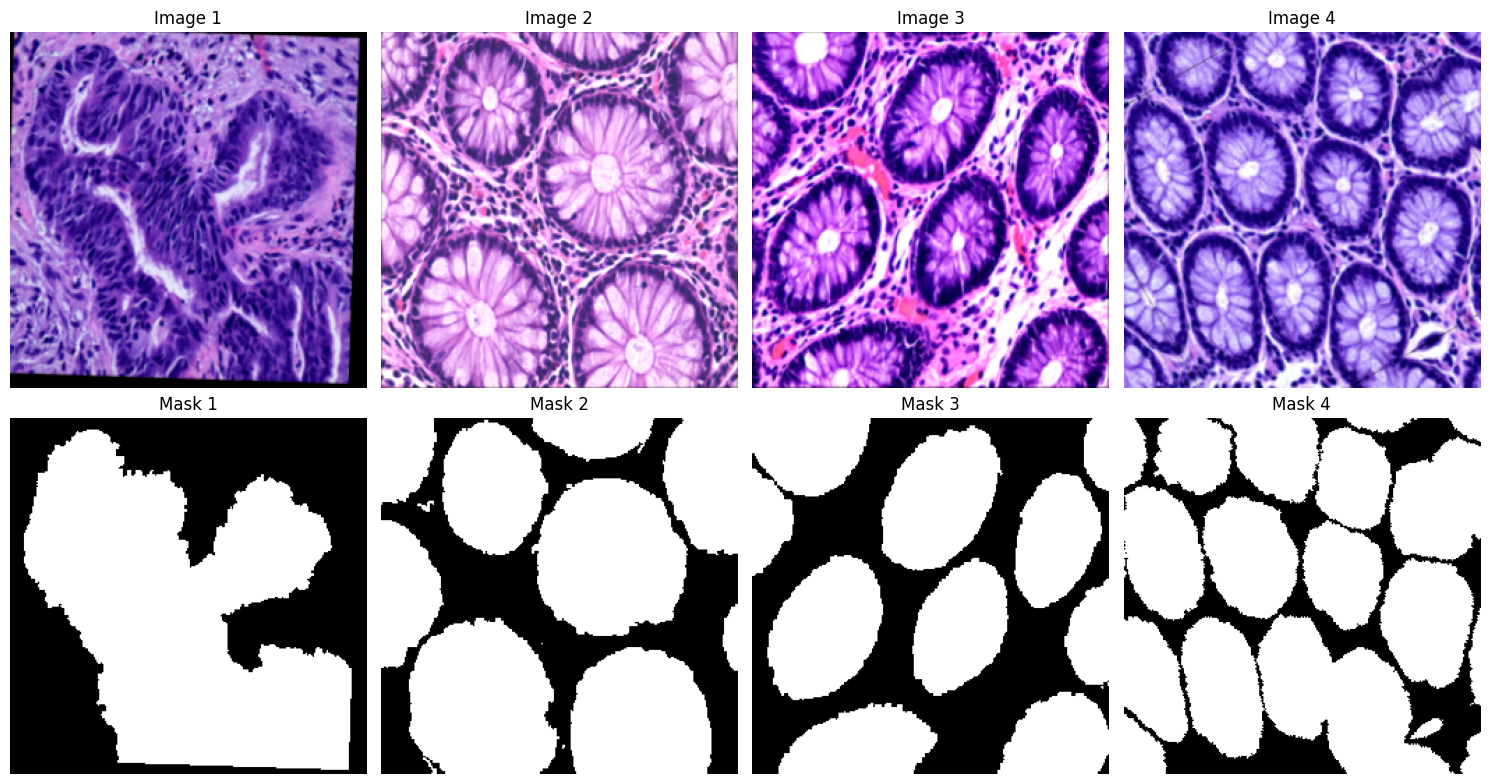

In [54]:

images, masks = next(iter(train_loader))
images = images.cpu()
maps = masks.cpu()
display_images = images

num_samples_to_show = min(4, BATCH_SIZE)

plt.figure(figsize=(15, 8))
for i in range(num_samples_to_show):
    # Original Image
    plt.subplot(2, num_samples_to_show, i + 1)
    plt.imshow(display_images[i].permute(1, 2, 0))
    plt.title(f'Image {i+1}')
    plt.axis('off')

    # Corresponding Mask
    plt.subplot(2, num_samples_to_show, i + 1 + num_samples_to_show)
    plt.imshow(maps[i].squeeze(0), cmap='gray') # Squeeze channel dimension for grayscale mask
    plt.title(f'Mask {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [55]:
def conv_bn_leru(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
  """
  Implements the sequence of: convolution, batch normalization, and relu activation function (x2)
  """

  return nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
          nn.BatchNorm2d(out_channels),
          nn.ReLU(inplace=True),
          nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
          nn.BatchNorm2d(out_channels),
          nn.ReLU(inplace=True),
  )


def down_pooling():
  """
  Max pooling operation, with a kernel size of 2x2 and a stride of 2
  """
  return nn.MaxPool2d(2, stride = 2)


def up_pooling(in_channels, out_channels, kernel_size=2, stride=2):
    """
    Perform the up scaling operation
    """
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )


class UNet(nn.Module):
    """U-Net architecture"""

    def __init__(self, input_channels, nclasses):
        super().__init__()

        self.nclasses = nclasses
        # Encoding layers
        self.conv1 = conv_bn_leru(input_channels,16)
        self.conv2 = conv_bn_leru(16, 32)
        self.conv3 = conv_bn_leru(32, 64)
        self.conv4 = conv_bn_leru(64, 128)
        self.conv5 = conv_bn_leru(128, 256)
        self.down_pooling = down_pooling()

        # Decoding layers
        self.up_pool6 = up_pooling(256, 128)
        self.conv6 = conv_bn_leru(256, 128)
        self.up_pool7 = up_pooling(128, 64)
        self.conv7 = conv_bn_leru(128, 64)
        self.up_pool8 = up_pooling(64, 32)
        self.conv8 = conv_bn_leru(64, 32)
        self.up_pool9 = up_pooling(32, 16)
        self.conv9 = conv_bn_leru(32, 16)

        self.conv10 = nn.Conv2d(16, self.nclasses, 1)
        self.softmax = nn.Softmax(dim=1)


    def forward(self, x):
        # --- Encoder ---
        x1 = self.conv1(x)
        p1 = self.down_pooling(x1)
        x2 = self.conv2(p1)
        p2 = self.down_pooling(x2)
        x3 = self.conv3(p2)
        p3 = self.down_pooling(x3)
        x4 = self.conv4(p3)
        p4 = self.down_pooling(x4)
        x5 = self.conv5(p4)

        # --- Decoder ---
        p6 = self.up_pool6(x5)
        x6 = torch.cat([p6, x4], dim=1)
        x6 = self.conv6(x6)

        p7 = self.up_pool7(x6)
        x7 = torch.cat([p7, x3], dim=1)
        x7 = self.conv7(x7)

        p8 = self.up_pool8(x7)
        x8 = torch.cat([p8, x2], dim=1)
        x8 = self.conv8(x8)

        p9 = self.up_pool9(x8)
        x9 = torch.cat([p9, x1], dim=1)
        x9 = self.conv9(x9)

        output = self.conv10(x9)

        return output


In [56]:
print("Checking batch shapes:")

# Get a batch from the train dataloader
for images, masks in train_loader:
    print(f"Train Dataloader - Images shape: {images.shape}")
    print(f"Train Dataloader - Masks shape: {masks.shape}")
    break

# Get a batch from the val dataloader
for images, masks in val_loader:
    print(f"Validation Dataloader - Images shape: {images.shape}")
    print(f"Validation Dataloader - Masks shape: {masks.shape}")
    break

Checking batch shapes:
Train Dataloader - Images shape: torch.Size([8, 3, 256, 256])
Train Dataloader - Masks shape: torch.Size([8, 1, 256, 256])
Validation Dataloader - Images shape: torch.Size([8, 3, 256, 256])
Validation Dataloader - Masks shape: torch.Size([8, 1, 256, 256])


In [57]:
def dice_score(pred, target):
    smooth = 1e-6
    intersection = torch.sum(pred * target)
    return (2. * intersection + smooth) / (torch.sum(pred) + torch.sum(target) + smooth)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels_flat = []
    all_preds_flat = []
    dice_total = 0.0
    num_samples = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        # Apply sigmoid to get probabilities
        outputs = torch.sigmoid(outputs)

        # loss computation
        loss = criterion(outputs, labels)

        # Backward pass and update weights
        loss.backward()
        optimizer.step()

        # Update statistics
        running_loss += loss.item() * inputs.size(0)

        # Threshold to get binary prediction
        preds = (outputs > 0.5).float()

        for i in range(inputs.size(0)):
            dice_total += dice_score(preds[i], labels[i])

        # Collect all labels and predictions and flatten them for F1 score computation
        all_labels_flat.extend(labels.cpu().numpy().flatten())
        all_preds_flat.extend(preds.cpu().numpy().flatten())

        num_samples += inputs.size(0)

    epoch_loss = running_loss / num_samples
    epoch_dice = dice_total / num_samples

    f1 = f1_score(all_labels_flat, all_preds_flat, average='binary')

    return epoch_loss, f1, epoch_dice

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels_flat = []
    all_preds_flat = []
    dice_total = 0.0
    num_samples = 0

    # disable gradients
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            # Apply sigmoid to get probabilities
            outputs = torch.sigmoid(outputs)

            # loss computation
            loss = criterion(outputs, labels)

            # Update statistics
            running_loss += loss.item() * inputs.size(0)

            # Threshold to get binary prediction
            preds = (outputs > 0.5).float()


            for i in range(inputs.size(0)):
                dice_total += dice_score(preds[i], labels[i])

            all_labels_flat.extend(labels.cpu().numpy().flatten())
            all_preds_flat.extend(preds.cpu().numpy().flatten())

            num_samples += inputs.size(0)

    epoch_loss = running_loss / num_samples
    epoch_dice = dice_total / num_samples # get average dice

    f1 = f1_score(all_labels_flat, all_preds_flat, average='binary')

    return epoch_loss, f1, epoch_dice

def train_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    best_f1 = 0.0  # initialize best f1 score
    best_model_wts = model.state_dict()  # Save the best model's weights

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        # --- Train ---
        train_loss, train_f1, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, device)
        print(f'Training Loss: {train_loss:.4f}, F1: {train_f1:.4f}, Dice: {train_dice:.4f}')

        # --- Validate ---
        val_loss, val_f1, val_dice = validate_one_epoch(model, val_loader, criterion, device)
        print(f'Validation Loss: {val_loss:.4f}, F1: {val_f1:.4f}, Dice: {val_dice:.4f}')

        # Save the model with the best f1 score
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_wts = model.state_dict()
            print('Best model updated!')

    # Load the best model weights
    model.load_state_dict(best_model_wts)
    print(f'Best model F1 score: {best_f1:.4f}')

    return model

In [58]:
model = UNet(input_channels=3, nclasses=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCEWithLogitsLoss()  # For binary segmentation
num_epochs = 5

print(model)


UNet(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [59]:
print("Checking model input and output dimensions:")
images, masks = next(iter(train_loader))
images = images.to(device)
print(f"Input image batch shape: {images.shape}")
model_output = model(images)
print(f"Model output batch shape: {model_output.shape}")

Checking model input and output dimensions:
Input image batch shape: torch.Size([8, 3, 256, 256])
Model output batch shape: torch.Size([8, 1, 256, 256])


In [60]:
trained_model = train_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

Epoch 1/5
Training Loss: 0.5910, F1: 0.8251, Dice: 0.8122
Validation Loss: 0.6521, F1: 0.7827, Dice: 0.7725
Best model updated!
Epoch 2/5
Training Loss: 0.5581, F1: 0.8775, Dice: 0.8700
Validation Loss: 0.5448, F1: 0.8443, Dice: 0.8315
Best model updated!
Epoch 3/5
Training Loss: 0.5444, F1: 0.8853, Dice: 0.8833
Validation Loss: 0.5437, F1: 0.8761, Dice: 0.8759
Best model updated!
Epoch 4/5
Training Loss: 0.5366, F1: 0.8853, Dice: 0.8817
Validation Loss: 0.5205, F1: 0.9188, Dice: 0.9186
Best model updated!
Epoch 5/5
Training Loss: 0.5267, F1: 0.8944, Dice: 0.8928
Validation Loss: 0.5607, F1: 0.7465, Dice: 0.7458
Best model F1 score: 0.9188


## Visualize some of the predictions

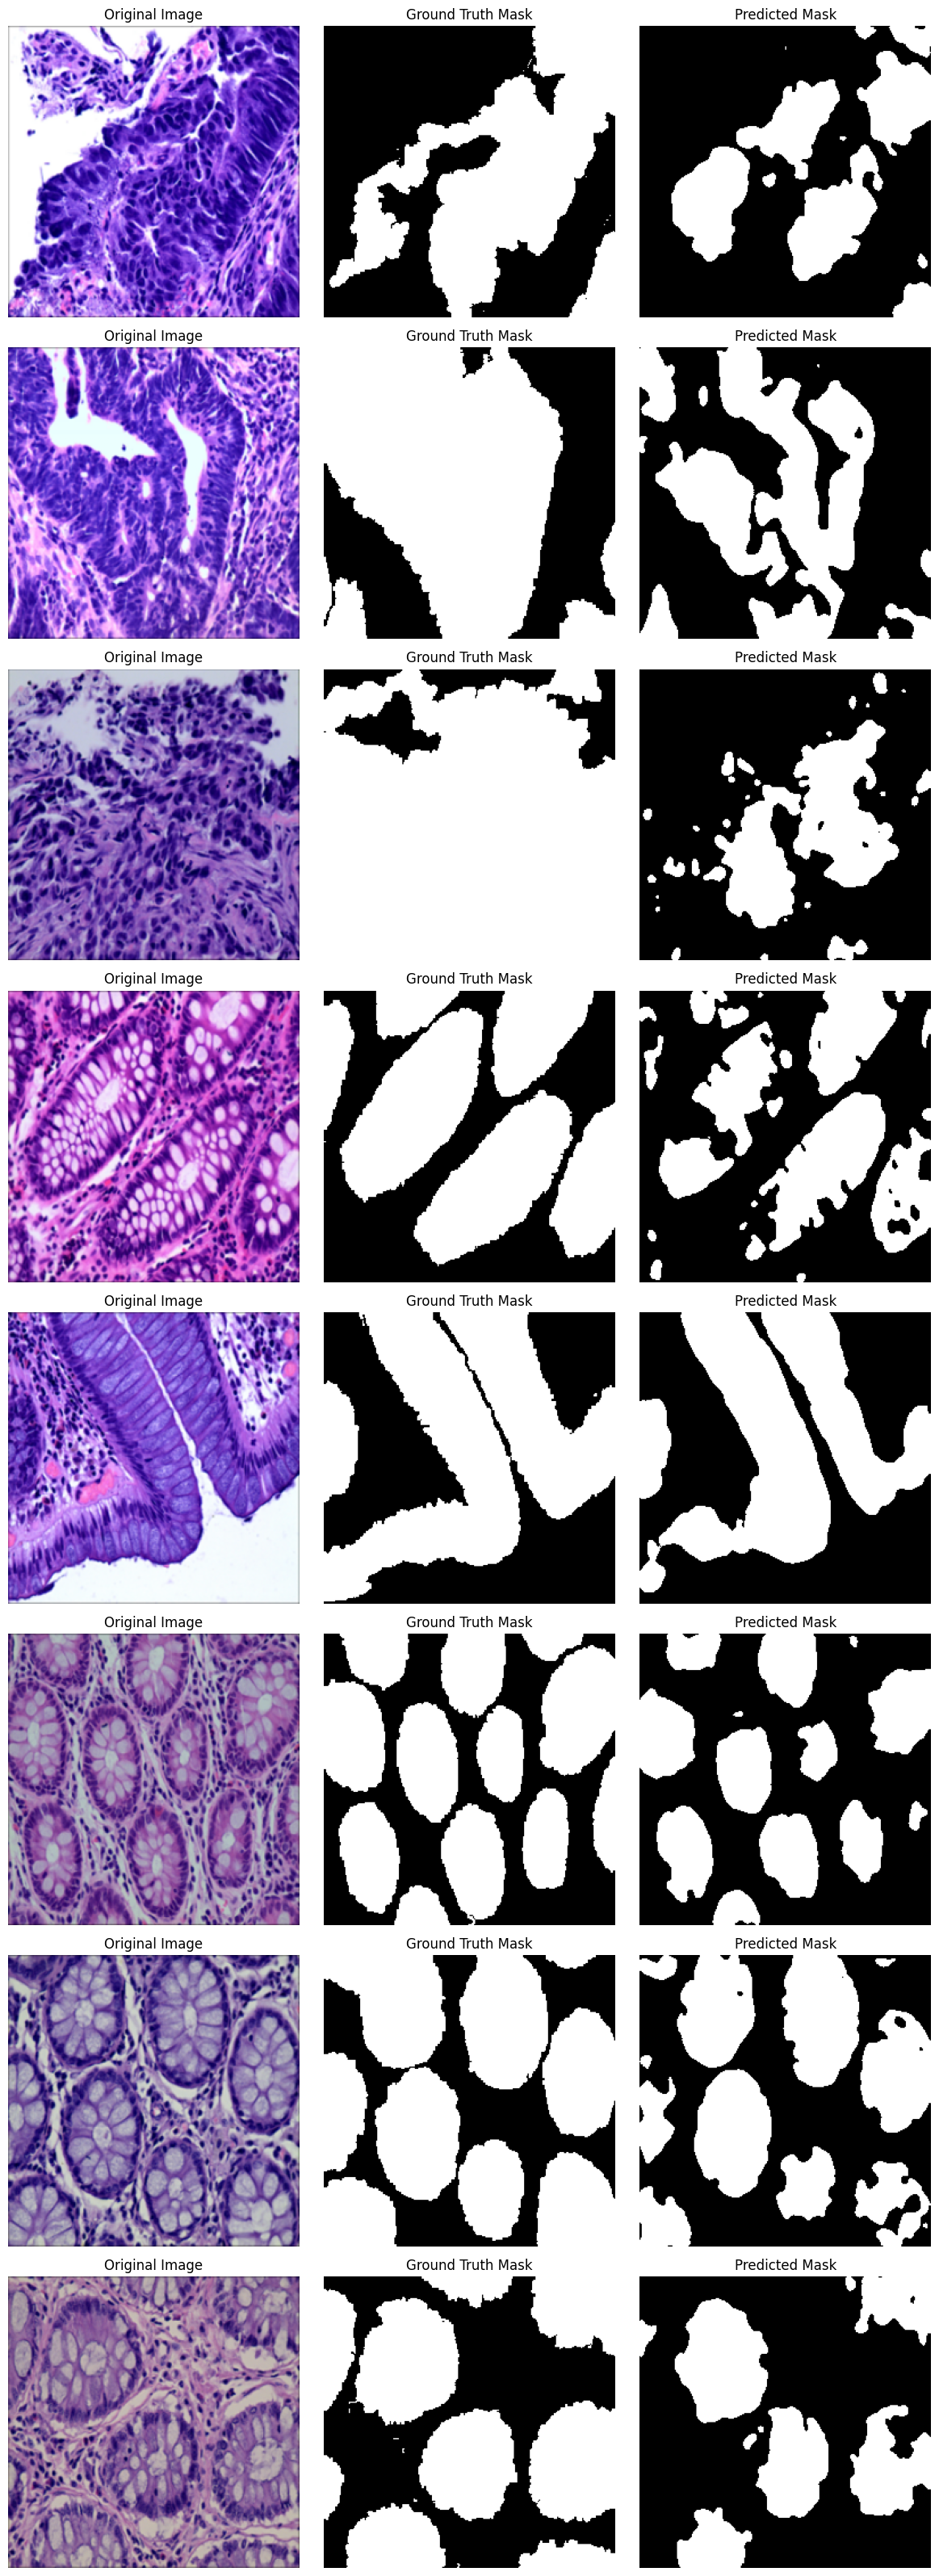

In [62]:
trained_model.eval()

images = []
ground_truths = []
predictions = []

num_images = 8

with torch.no_grad():
    for i, (inputs, labels) in enumerate(val_loader):
        if i == num_images:
            break

        inputs, labels = inputs.to(device), labels.to(device)

        outputs = trained_model(inputs)
        outputs = torch.sigmoid(outputs)


        preds = (outputs > 0.5).float()


        images.append(inputs.cpu().numpy())
        ground_truths.append(labels.cpu().numpy())
        predictions.append(preds.cpu().numpy())


fig, axes = plt.subplots(num_images, 3, figsize=(12, num_images * 4))
for i in range(num_images):
    ax = axes[i, 0]
    ax.imshow(images[i][0].transpose(1, 2, 0))
    ax.set_title('Original Image')
    ax.axis('off')

    ax = axes[i, 1]
    ax.imshow(ground_truths[i][0].transpose(1, 2, 0), cmap='gray')
    ax.set_title('Ground Truth Mask')
    ax.axis('off')

    ax = axes[i, 2]
    ax.imshow(predictions[i][0].transpose(1, 2, 0), cmap='gray')
    ax.set_title('Predicted Mask')
    ax.axis('off')

plt.tight_layout()
plt.show()
